#Enviroment setup

In [1]:
# needs to run twice, in separate sessions
!pip install "numpy<2.0.0" "pandas<2.2.0" meteostat==1.6.7

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import xgboost as xgb
import holidays
import warnings
import shutil
from meteostat import Point, Daily

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import xgboost as xgb

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# !!! ACTION REQUIRED !!! - update paths for your project structure

DRIVE_PATH = '/content/drive/MyDrive/DP'

DATA_DIR = f'{DRIVE_PATH}/00_data/dehiwala_mc_2012-2018.csv'
RES_DIR = f'{DRIVE_PATH}/02_processed_data'
VIS_DIR = f'{DRIVE_PATH}/03_visualizations/EDA/Dehiwala'

# Data Load

In [4]:
print("=" * 100)
print("DATASET OVERVIEW")
print("=" * 100)

try:
    df = pd.read_csv(DATA_DIR)
    print(f"\nDataset loaded from DATA_PATH:")
    print(f"  Rows: {len(df):,} | Columns: {len(df.columns)}")
    print(f"  Columns: {list(df.columns)}")
except Exception as e:
    print(f"\nError loading dataset from DATA_PATH: {e}")

DATASET OVERVIEW

Dataset loaded from DATA_PATH:
  Rows: 3,583 | Columns: 4
  Columns: ['area', 'ticket_date', 'waste_type', 'net_weight_kg']


## Data Preview

In [5]:
df_raw = pd.read_csv(DATA_DIR)
df_raw['ticket_date'] = pd.to_datetime(df_raw['ticket_date'])
df_raw = df_raw[df_raw['ticket_date'] < '2016-01-01']

print("=" * 100)
print(f"DATASET LOADED FROM: {DATA_DIR}")
print("=" * 100)
print(f"\nNumber of records: {len(df_raw):,}")
print(f"Waste Types: {df_raw['waste_type'].unique()}")
print(f"\nData Sample:")
df_raw.head()

DATASET LOADED FROM: /content/drive/MyDrive/DP/00_data/dehiwala_mc_2012-2018.csv

Number of records: 1,623
Waste Types: ['Non Biodegradable' 'Biodegradable' 'Sorted Organic Waste'
 'Polythyne & Regiform' 'MSW']

Data Sample:


,area,ticket_date,waste_type,net_weight_kg
0,Dehiwala MC,2012-01-01,Non Biodegradable,82270
1,Dehiwala MC,2012-01-02,Non Biodegradable,123010
2,Dehiwala MC,2012-01-03,Non Biodegradable,128330
3,Dehiwala MC,2012-01-04,Non Biodegradable,79430
4,Dehiwala MC,2012-01-05,Non Biodegradable,121320


In [6]:
# waste type filtering
MSW_TYPES = ['MSW', 'Sorted Organic Waste', 'Polythyne & Regiform', 'Non Biodegradable', 'Biodegradable']
df_filtered = df_raw[df_raw['waste_type'].isin(MSW_TYPES)]
print(f"Records after MSW filter: {len(df_filtered):,} (from {len(df_raw):,})")
print(f"Kept waste types: {df_filtered['waste_type'].unique()}")

# aggregating into daily totals
daily = df_filtered.groupby('ticket_date')['net_weight_kg'].sum().reset_index()
daily.columns = ['date', 'total_kg']
daily = daily.sort_values('date').reset_index(drop=True)

# conversion to tonnes for readability
daily['total_tonnes'] = daily['total_kg'] / 1000

print(f"Number of Days: {len(daily)}")
print(f"Date Range: {daily['date'].min().date()} → {daily['date'].max().date()}")

Records after MSW filter: 1,623 (from 1,623)
Kept waste types: ['Non Biodegradable' 'Biodegradable' 'Sorted Organic Waste'
 'Polythyne & Regiform' 'MSW']
Number of Days: 1433
Date Range: 2012-01-01 → 2015-12-31


# Gap Analysis

In [7]:
print("=" * 100)
print("GAP ANALYSIS & CONDITIONAL IMPUTATION")
print("=" * 100)

# full data range
full_range = pd.date_range(daily['date'].min(), daily['date'].max(), freq='D')
daily = daily.set_index('date').reindex(full_range).rename_axis('date').reset_index()

total_days = len(daily)

# initial short gap identification
daily['is_missing'] = daily['total_kg'].isna()
daily['_gap_group'] = (daily['is_missing'] != daily['is_missing'].shift()).cumsum()
daily['was_gap'] = daily['is_missing'].copy()

initial_gaps = daily[daily['is_missing']].groupby('_gap_group').agg(
    start=('date', 'first'),
    end=('date', 'last'),
    length=('date', 'count')
).reset_index(drop=True)

# gap imputation (0 if length 1-3 AND next day > 1.15 * previous 30d avg)
imputed_gaps_count = 0
imputed_days_count = 0

for _, gap in initial_gaps.iterrows():
    if 1 <= gap['length'] <= 3:
        day_before = gap['start'] - pd.Timedelta(days=1)
        day_after = gap['end'] + pd.Timedelta(days=1)

        # 30 day avg
        window_start = day_before - pd.Timedelta(days=29)
        past_30_days = daily[(daily['date'] >= window_start) & (daily['date'] <= day_before)]
        avg_30d_before = past_30_days['total_kg'].mean()

        # value after gap
        val_after_series = daily.loc[daily['date'] == day_after, 'total_kg']
        if not val_after_series.empty and pd.notna(avg_30d_before):
            val_after = val_after_series.values[0]

            if pd.notna(val_after) and val_after >= 1.15 * avg_30d_before:
                mask = (daily['date'] >= gap['start']) & (daily['date'] <= gap['end'])
                daily.loc[mask, 'total_kg'] = 0

                imputed_gaps_count += 1
                imputed_days_count += gap['length']

print(f"\n--- Imputation Summary ---")
print(f"Condition: Gaps of 1-3 days filled with 0 IF day after > 1.15 * 30d avg before.")
print(f"Imputed {imputed_gaps_count} gaps (total {imputed_days_count} days).")


daily['is_missing'] = daily['total_kg'].isna()
missing_count = daily['is_missing'].sum()
has_data_count = total_days - missing_count

print(f"\nTotal Date Range: {daily['date'].min().date()} → {daily['date'].max().date()}")
print(f"Total Days: {total_days}")
print(f"Days WITH data: {has_data_count} ({has_data_count/total_days*100:.1f}%)")
print(f"Days WITHOUT data (NaN): {missing_count} ({missing_count/total_days*100:.1f}%)")


# rest of gap identification
daily['_gap_group'] = (daily['is_missing'] != daily['is_missing'].shift()).cumsum()
gaps = daily[daily['is_missing']].groupby('_gap_group').agg(
    start=('date', 'first'),
    end=('date', 'last'),
    length=('date', 'count')
).reset_index(drop=True)
daily = daily.drop(columns=['_gap_group'])

print(f"\nTotal REMAINING gaps: {len(gaps)}")
if len(gaps) > 0:
    print(f"Longest gap: {gaps['length'].max()} days")
    print(f"Median gap: {gaps['length'].median():.0f} days")

    # gap size distribution
    print(f"\nGap size distribution:")
    print(f"  1 day:      {(gaps['length'] == 1).sum()} gaps")
    print(f"  2-4 days:   {((gaps['length'] >= 2) & (gaps['length'] <= 4)).sum()} gaps")
    print(f"  5-14 days:  {((gaps['length'] >= 5) & (gaps['length'] <= 14)).sum()} gaps")
    print(f"  15-30 days: {((gaps['length'] >= 15) & (gaps['length'] <= 30)).sum()} gaps")
    print(f"  30+ days:   {(gaps['length'] > 30).sum()} gaps")

    print(f"\nRemaining gaps (top 20 by length):")
    for _, gap in gaps.sort_values('length', ascending=False).head(20).iterrows():
        print(f"  {gap['start'].date()} → {gap['end'].date()} ({gap['length']} days)")

# summary
print(f"\n--- Year-by-year ---")
daily['year'] = daily['date'].dt.year
for year in sorted(daily['year'].unique()):
    yd = daily[daily['year'] == year]
    ym = yd['is_missing'].sum()
    yt = len(yd)
    yg = gaps[(gaps['start'].dt.year <= year) & (gaps['end'].dt.year >= year)]
    mg = yg['length'].max() if len(yg) > 0 else 0
    print(f"  {year}: {yt-ym}/{yt} days with data ({(yt-ym)/yt*100:.1f}%), longest gap: {mg}d")

GAP ANALYSIS & CONDITIONAL IMPUTATION

--- Imputation Summary ---
Condition: Gaps of 1-3 days filled with 0 IF day after > 1.15 * 30d avg before.
Imputed 3 gaps (total 5 days).

Total Date Range: 2012-01-01 → 2015-12-31
Total Days: 1461
Days WITH data: 1438 (98.4%)
Days WITHOUT data (NaN): 23 (1.6%)

Total REMAINING gaps: 5
Longest gap: 16 days
Median gap: 2 days

Gap size distribution:
  1 day:      2 gaps
  2-4 days:   2 gaps
  5-14 days:  0 gaps
  15-30 days: 1 gaps
  30+ days:   0 gaps

Remaining gaps (top 20 by length):
  2014-10-16 → 2014-10-31 (16 days)
  2015-10-04 → 2015-10-06 (3 days)
  2015-03-14 → 2015-03-15 (2 days)
  2013-05-04 → 2013-05-04 (1 days)
  2015-05-15 → 2015-05-15 (1 days)

--- Year-by-year ---
  2012: 366/366 days with data (100.0%), longest gap: 0d
  2013: 364/365 days with data (99.7%), longest gap: 1d
  2014: 349/365 days with data (95.6%), longest gap: 16d
  2015: 359/365 days with data (98.4%), longest gap: 3d


# Feature Engineering

## Holidays

In [8]:
def get_sri_lanka_holidays(start_year, end_year):
    """Fetch Sri Lankan public holidays including Poya days via 'holidays' library."""
    all_holidays = []
    sri_lanka_holidays = holidays.country_holidays('LK', years=range(start_year, end_year + 1))

    for date, name in sri_lanka_holidays.items():
        all_holidays.append({
            'date': pd.to_datetime(date),
            'holiday_name': name
        })

    return pd.DataFrame(all_holidays)

# fetching holidays
holidays_df = get_sri_lanka_holidays(daily['date'].dt.year.min(), daily['date'].dt.year.max())
holiday_dates = set(holidays_df['date'].values)

# creating calendar features
daily['year'] = daily['date'].dt.year
daily['month'] = daily['date'].dt.month
daily['day_of_week'] = daily['date'].dt.dayofweek
daily['day_of_year'] = daily['date'].dt.dayofyear
daily['week_of_year'] = daily['date'].dt.isocalendar().week.astype(int)
daily['is_weekend'] = (daily['day_of_week'] >= 5).astype(int)
daily['is_holiday'] = daily['date'].isin(holiday_dates).astype(int)
daily['is_after_weekend'] = (daily['day_of_week'] == 0).astype(int)
daily['is_after_holiday'] = daily['is_holiday'].shift(1).fillna(0).astype(int)
daily['is_after_gap'] = daily['was_gap'].shift(1).fillna(False).astype(int)

print(holidays_df)

         date                           holiday_name
0  2012-01-15                  Tamil Thai Pongal Day
1  2012-02-04                       Independence Day
2  2012-04-13             Sinhala and Tamil New Year
3  2012-04-12  Day Before Sinhala and Tamil New Year
4  2012-04-06    Bak Full Moon Poya Day; Good Friday
..        ...                                    ...
94 2015-11-25                  Il Full Moon Poya Day
95 2015-12-24             Unduvap Full Moon Poya Day
96 2015-07-18                            Eid al-Fitr
97 2015-09-24                            Eid al-Adha
98 2015-07-01          Adhi Esala Full Moon Poya Day

[99 rows x 2 columns]


## Weather

In [9]:
# clearing Meteostat cache
cache_dir = os.path.expanduser('~/.meteostat/cache')

if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)
    print("Meteostat cache successfully wiped!")
else:
    print("No cache found.")

No cache found.


In [10]:
print("=" * 100)
print("Fetching historical weather data via Meteostat...")
print("=" * 100)

# fetching daily weather for Dehiwala (lat, lon, altitude)
location = Point(6.8569, 79.8650, 10)
start_date = daily['date'].min().to_pydatetime()
end_date = daily['date'].max().to_pydatetime()

weather_data = Daily(location, start_date, end_date)
weather_data = weather_data.fetch().reset_index()

# renaming the meteostat 'time' column to 'date'
weather_data = weather_data.rename(columns={'time': 'date'})

# selecting only relevant features: temperature, precipitation, wind speed
weather_features = weather_data[['date', 'tavg', 'prcp']]

# ============================================================
# MISSING WEATHER DATA CHECK (BEFORE FILLING)
# ============================================================
print("\n--- Missing Weather Data (Meteostat raw) ---")
total_w_days = len(weather_features)
print(f"Total days fetched: {total_w_days}")

for col in ['tavg', 'prcp']:
    missing = weather_features[col].isna().sum()
    pct = (missing / total_w_days) * 100
    print(f"  {col.ljust(5)}: {missing} missing days ({pct:.1f}%)")
print("-" * 44)
# ============================================================

# cleaning up missing weather data
weather_features = weather_features.ffill().bfill()

# merging weather into the dataset + doublecheck
daily = pd.merge(daily, weather_features, on='date', how='left')
daily[['tavg', 'prcp']] = daily[['tavg', 'prcp']].ffill().bfill()

print("\nWeather data successfully fetched and merged!")
print(daily[['date', 'tavg', 'prcp']].head())

Fetching historical weather data via Meteostat...

--- Missing Weather Data (Meteostat raw) ---
Total days fetched: 1461
  tavg : 0 missing days (0.0%)
  prcp : 1 missing days (0.1%)
--------------------------------------------

Weather data successfully fetched and merged!
        date  tavg  prcp
0 2012-01-01  25.6   0.0
1 2012-01-02  26.2   0.0
2 2012-01-03  27.3   0.0
3 2012-01-04  27.7   0.0
4 2012-01-05  26.9   0.0


## Lag & Rolling features

In [11]:
print("=" * 100)
print("FEATURE ENGENEERING: ROLLING, CYCLICAL, AND LAG FEATURES")
print("=" * 100)

# rolling window statistics
daily['rolling_7_mean'] = daily['total_tonnes'].shift(1).rolling(7, min_periods=1).mean()
daily['rolling_7_std']  = daily['total_tonnes'].shift(1).rolling(7, min_periods=1).std()
daily['rolling_30_mean'] = daily['total_tonnes'].shift(1).rolling(30, min_periods=1).mean()

# cyclical encoding for periodic features (month, day of week)
daily['month_sin'] = np.sin(2 * np.pi * daily['month'] / 12)
daily['month_cos'] = np.cos(2 * np.pi * daily['month'] / 12)
daily['dow_sin']   = np.sin(2 * np.pi * daily['day_of_week'] / 7)
daily['dow_cos']   = np.cos(2 * np.pi * daily['day_of_week'] / 7)

# lag features
for lag in [1, 2, 3, 7, 14, 30]:
    daily[f'lag_{lag}'] = daily['total_tonnes'].shift(lag)

print(f"Features created. Final shape: {daily.shape}")

FEATURE ENGENEERING: ROLLING, CYCLICAL, AND LAG FEATURES
Features created. Final shape: (1461, 30)


# Dataset Visualization

VISUALIZING DAILY WASTE DATA (gaps visible as breaks)


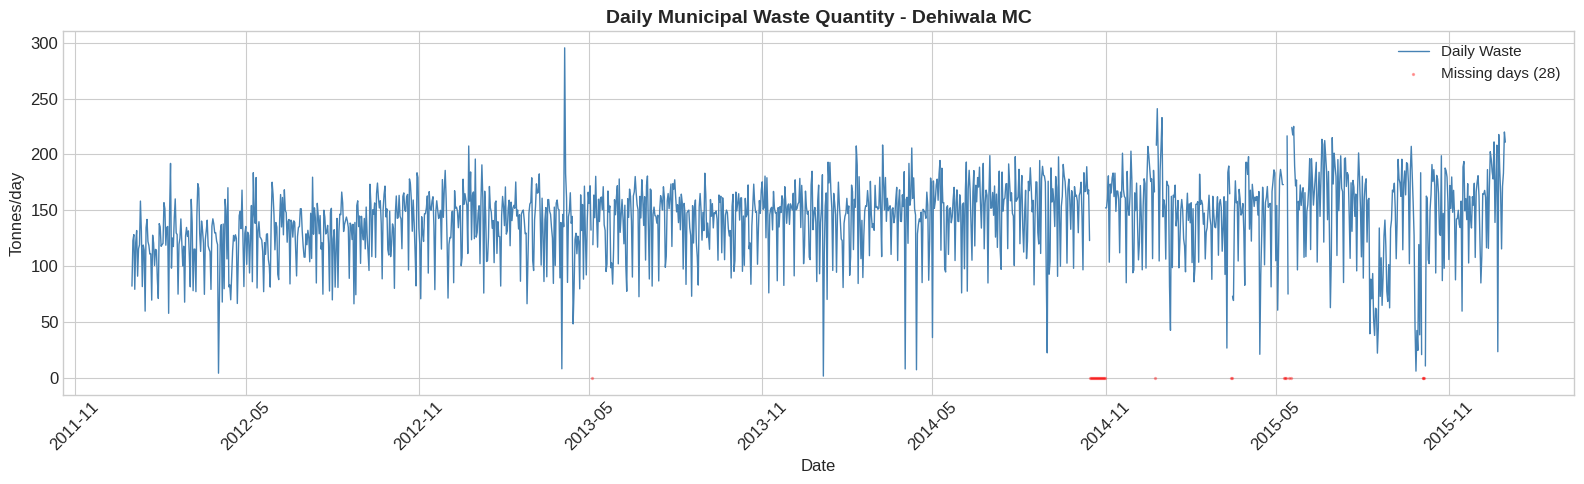

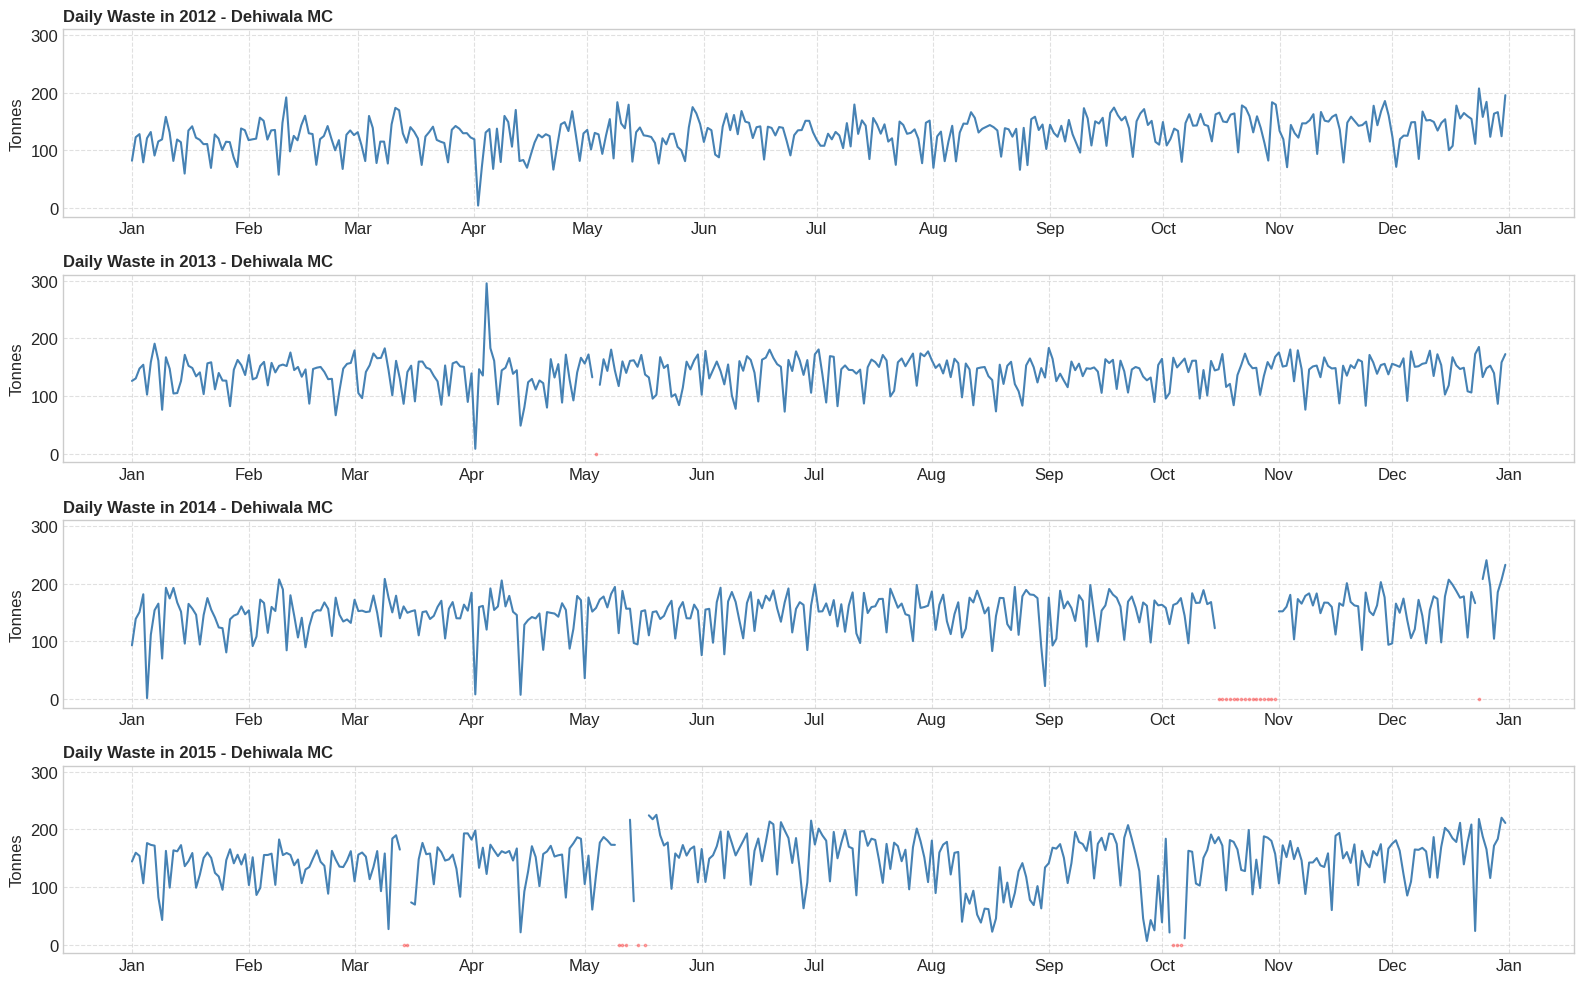

In [12]:
print("=" * 100)
print("VISUALIZING DAILY WASTE DATA (gaps visible as breaks)")
print("=" * 100)

# --- Plot 201: Full timeline with gaps visible - Dehiwala MC ---
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily['date'], daily['total_tonnes'], color='steelblue', linewidth=1, label='Daily Waste')

missing_dates = daily[daily['was_gap']]['date']
if not missing_dates.empty:
    ax.scatter(missing_dates, [0]*len(missing_dates), color='red', s=2, alpha=0.3, label=f'Missing days ({len(missing_dates)})', zorder=1)

ax.set_title('Daily Municipal Waste Quantity - Dehiwala MC', fontsize=14, fontweight='bold')
ax.set_ylabel('Tonnes/day')
ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.legend(fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(os.path.join(VIS_DIR, '201_base_data_full_timeline_de.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 202: Year-by-year breakdown - Dehiwala MC ---
years = sorted(daily['date'].dt.year.unique())
fig, axes = plt.subplots(len(years), 1, figsize=(16, 2.5 * len(years)), sharey=True)
if len(years) == 1:
    axes = [axes]

for i, year in enumerate(years):
    year_data = daily[daily['date'].dt.year == year]
    axes[i].plot(year_data['date'], year_data['total_tonnes'], color='steelblue', linewidth=1.5)
    yr_missing = year_data[year_data['was_gap']]
    if not yr_missing.empty:
        axes[i].scatter(yr_missing['date'], [0]*len(yr_missing), color='red', s=3, alpha=0.3)
    axes[i].set_title(f'Daily Waste in {year} - Dehiwala MC', fontsize=12, fontweight='bold', loc='left')
    axes[i].set_ylabel('Tonnes')
    axes[i].xaxis.set_major_locator(mdates.MonthLocator())
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

plt.savefig(os.path.join(VIS_DIR, '202_base_data_by_year_de.png'), dpi=150, bbox_inches='tight')
plt.show()

# Explanatory Data Analysis

VISUALIZING DAILY WASTE TIMESERIES


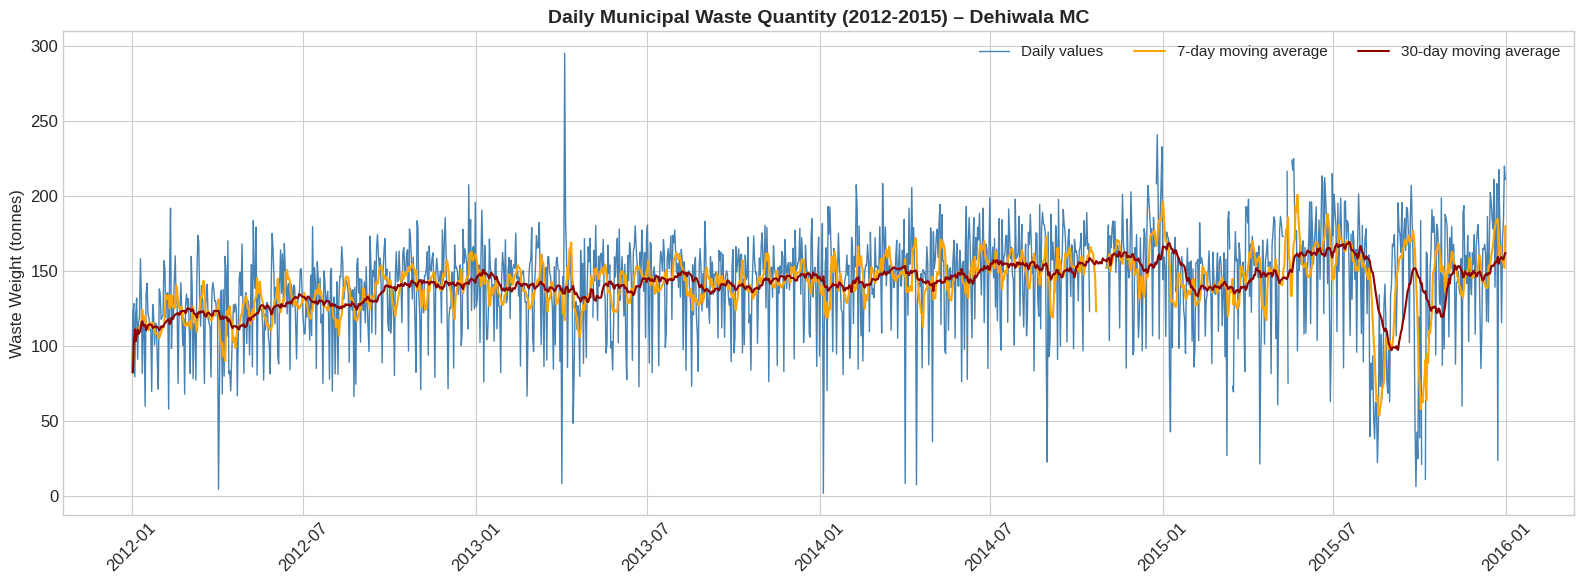

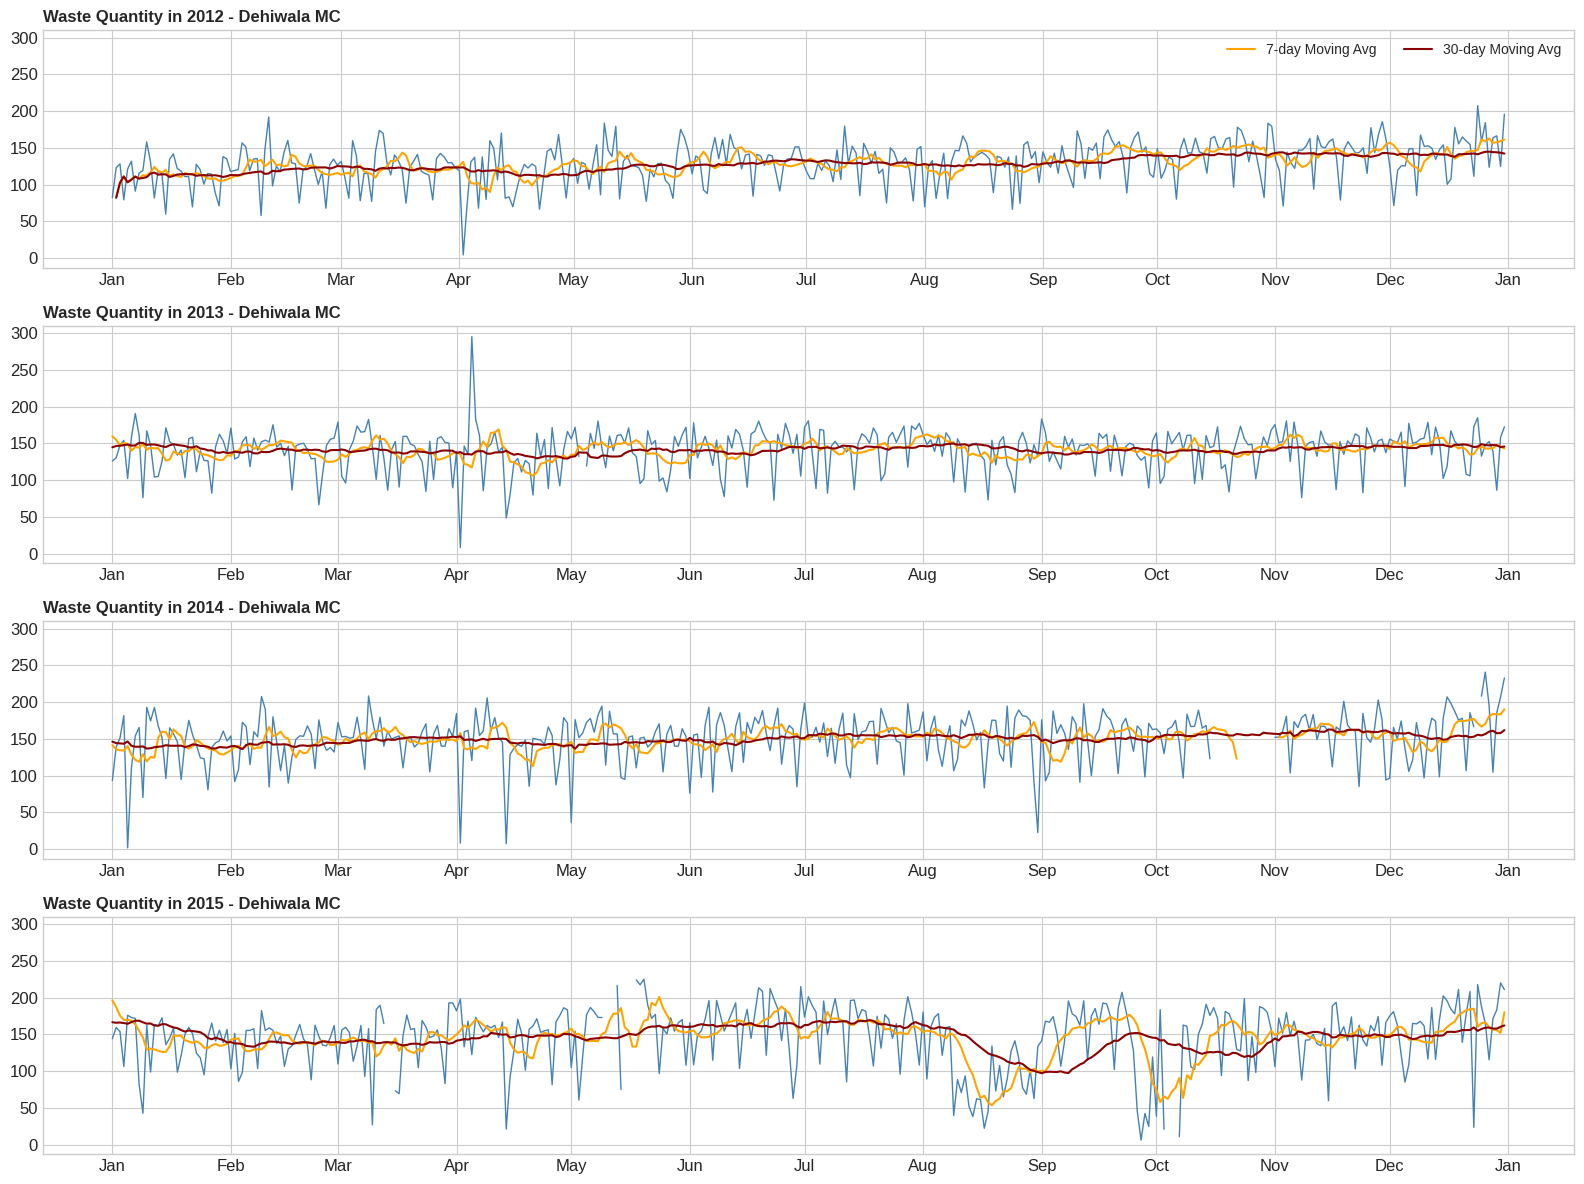

In [13]:
print("=" * 100)
print("VISUALIZING DAILY WASTE TIMESERIES")
print("=" * 100)

# --- Plot 211: Full timeline with rolling averages - Dehiwala MC ---
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(daily['date'], daily['total_tonnes'], linewidth=1, color='steelblue', label='Daily values')

ax.plot(daily['date'], daily['rolling_7_mean'], linewidth=1.5, color='orange', label='7-day moving average')
ax.plot(daily['date'], daily['rolling_30_mean'], linewidth=1.5, color='darkred', label='30-day moving average')

ax.set_title('Daily Municipal Waste Quantity (2012-2015) – Dehiwala MC', fontsize=14, fontweight='bold')
ax.set_ylabel('Waste Weight (tonnes)')
ax.legend(fontsize=11, loc='upper right', ncol=3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, '211_timeseries_full_timeline_de.png'), dpi=150, bbox_inches='tight')
plt.show()


# --- Plot 212: Year-by-year with rolling averages - Dehiwala MC ---
years = sorted(daily['year'].dropna().unique().astype(int))
fig, axes = plt.subplots(len(years), 1, figsize=(16, 3 * len(years)), sharey=True)

for i, year in enumerate(years):
    year_data = daily[daily['year'] == year]

    axes[i].plot(year_data['date'], year_data['total_tonnes'], color='steelblue', linewidth=1)

    axes[i].plot(year_data['date'], year_data['rolling_7_mean'], color='orange', linewidth=1.5, label='7-day Moving Avg')
    axes[i].plot(year_data['date'], year_data['rolling_30_mean'], color='darkred', linewidth=1.5, label='30-day Moving Avg')

    axes[i].set_title(f'Waste Quantity in {year} - Dehiwala MC', fontsize=12, fontweight='bold', loc='left')
    axes[i].xaxis.set_major_locator(mdates.MonthLocator())
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%b'))

    if i == 0:
        axes[i].legend(loc='upper right', fontsize=10, ncol=3)

plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, '212_timeseries_by_year_de.png'), dpi=150, bbox_inches='tight')
plt.show()

VISUALIZING WASTE DISTRIBUTION


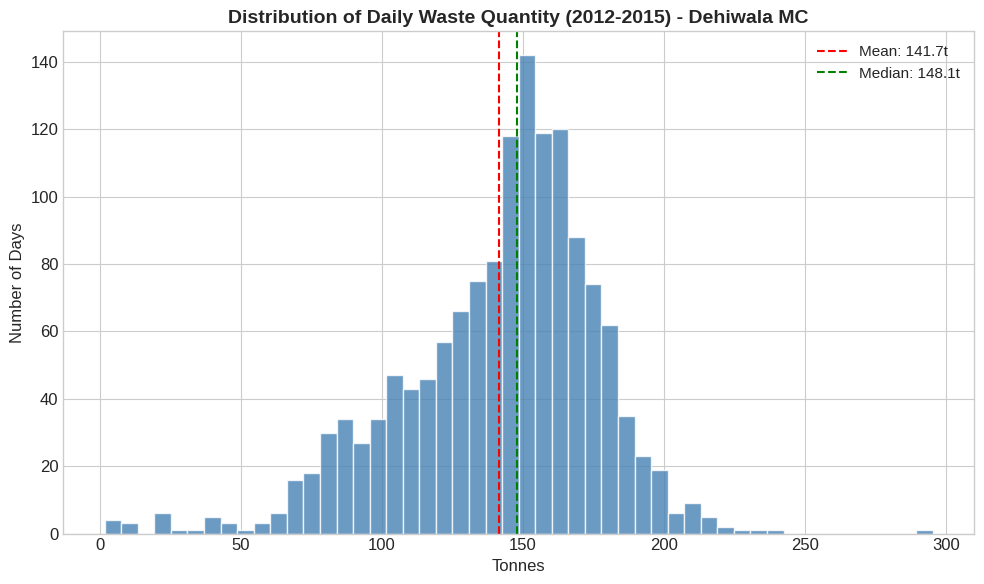

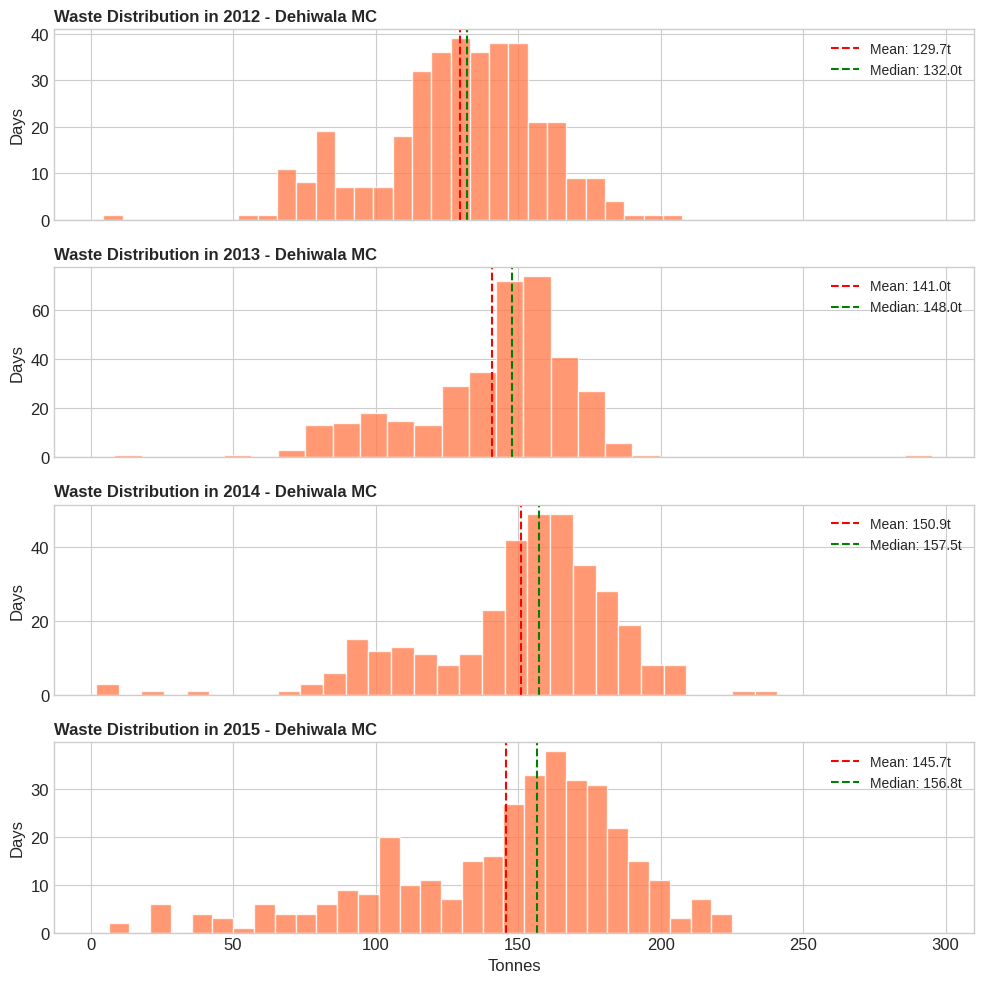

In [14]:
print("=" * 100)
print("VISUALIZING WASTE DISTRIBUTION")
print("=" * 100)


# --- Plot 221: Overall histogram with mean/median - Dehiwala MC ---
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(daily['total_tonnes'], bins=50, color='steelblue',
        edgecolor='white', alpha=0.8)

ax.axvline(daily['total_tonnes'].mean(), color='red', linestyle='--',
           label=f'Mean: {daily["total_tonnes"].mean():.1f}t')
ax.axvline(daily['total_tonnes'].median(), color='green', linestyle='--',
           label=f'Median: {daily["total_tonnes"].median():.1f}t')

ax.set_title('Distribution of Daily Waste Quantity (2012-2015) - Dehiwala MC',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Tonnes')
ax.set_ylabel('Number of Days')
ax.legend(fontsize=11)
plt.tight_layout()

plt.savefig(os.path.join(VIS_DIR, '221_waste_distribution_full_timeline_de.png'), dpi=150, bbox_inches='tight')
plt.show()


# --- Plot 222: Year-by-year comparison - Dehiwala MC ---
years = sorted(daily['year'].dropna().unique().astype(int))
fig, axes = plt.subplots(len(years), 1, figsize=(10, 2.5 * len(years)), sharex=True)

for i, year in enumerate(years):
    year_data = daily[daily['year'] == year]['total_tonnes'].dropna()

    axes[i].hist(year_data, bins=30, color='coral', edgecolor='white', alpha=0.8)

    y_mean = year_data.mean()
    y_median = year_data.median()

    axes[i].axvline(y_mean, color='red', linestyle='--', label=f'Mean: {y_mean:.1f}t')
    axes[i].axvline(y_median, color='green', linestyle='--', label=f'Median: {y_median:.1f}t')

    axes[i].set_title(f'Waste Distribution in {year} - Dehiwala MC', fontsize=12, fontweight='bold', loc='left')
    axes[i].set_ylabel('Days')
    axes[i].legend(loc='upper right', fontsize=10)

axes[-1].set_xlabel('Tonnes')
plt.tight_layout()

plt.savefig(os.path.join(VIS_DIR, '222_waste_distribution_by_year_de.png'), dpi=150, bbox_inches='tight')
plt.show()

VISUALIZING LONG-TERM TRENDS (Monthly Sums)


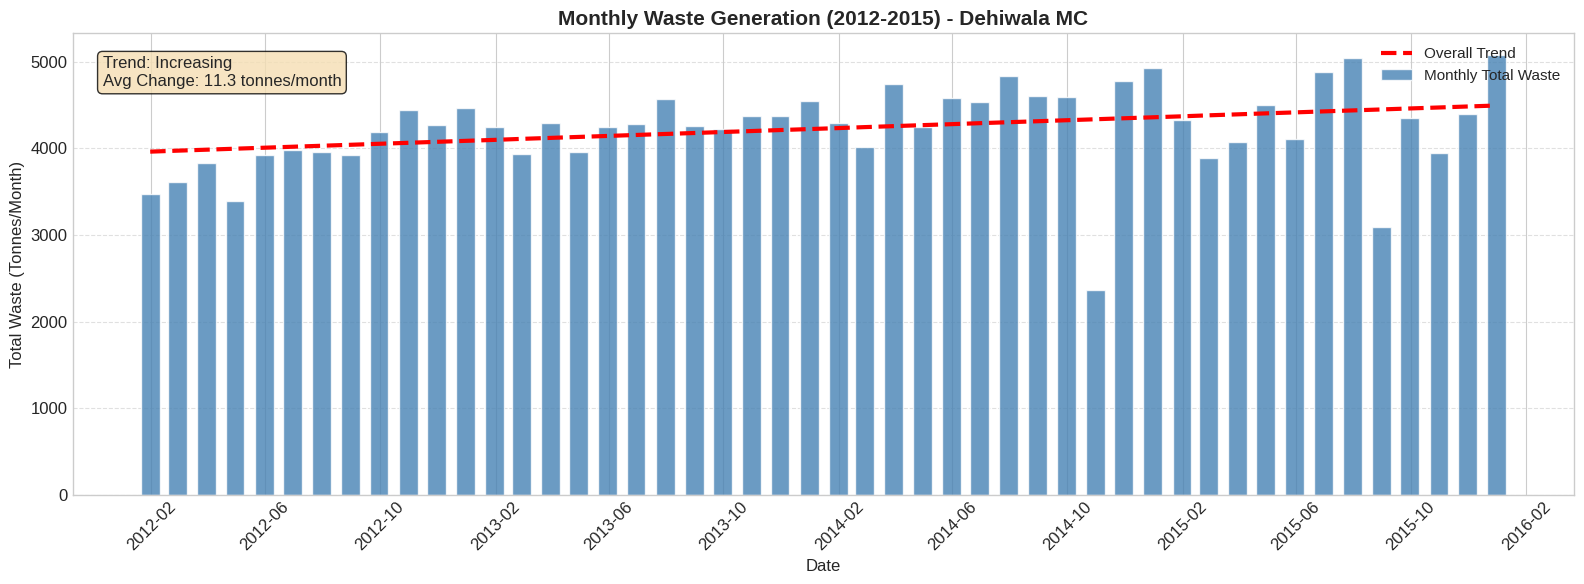

In [15]:
print("=" * 100)
print("VISUALIZING LONG-TERM TRENDS (Monthly Sums)")
print("=" * 100)


# --- Plot 231:  Monthly aggregation with linear trendline - Dehiwala MC ---
fig, ax = plt.subplots(figsize=(16, 6))

monthly_sum = daily.set_index('date').resample('M')['total_tonnes'].sum().reset_index()

ax.bar(monthly_sum['date'], monthly_sum['total_tonnes'], width=20,
       color='steelblue', edgecolor='white', alpha=0.8, label='Monthly Total Waste')

# fit linear trendline
x_numeric = np.arange(len(monthly_sum))
z = np.polyfit(x_numeric, monthly_sum['total_tonnes'].values, 1)
slope = z[0]
ax.plot(monthly_sum['date'], np.poly1d(z)(x_numeric), color='red',
        linestyle='--', linewidth=3, label='Overall Trend')

ax.set_title('Monthly Waste Generation (2012-2015) - Dehiwala MC', fontsize=15, fontweight='bold')
ax.set_ylabel('Total Waste (Tonnes/Month)')
ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.xticks(rotation=45)

trend_direction = "Increasing" if slope > 0 else "Decreasing"
ax.text(0.02, 0.95,
        f'Trend: {trend_direction}\nAvg Change: {slope:.1f} tonnes/month',
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, '231_monthly_trend_de.png'), dpi=150, bbox_inches='tight')
plt.show()

VISUALIZING MACRO SEASONALITY (Day of Week)


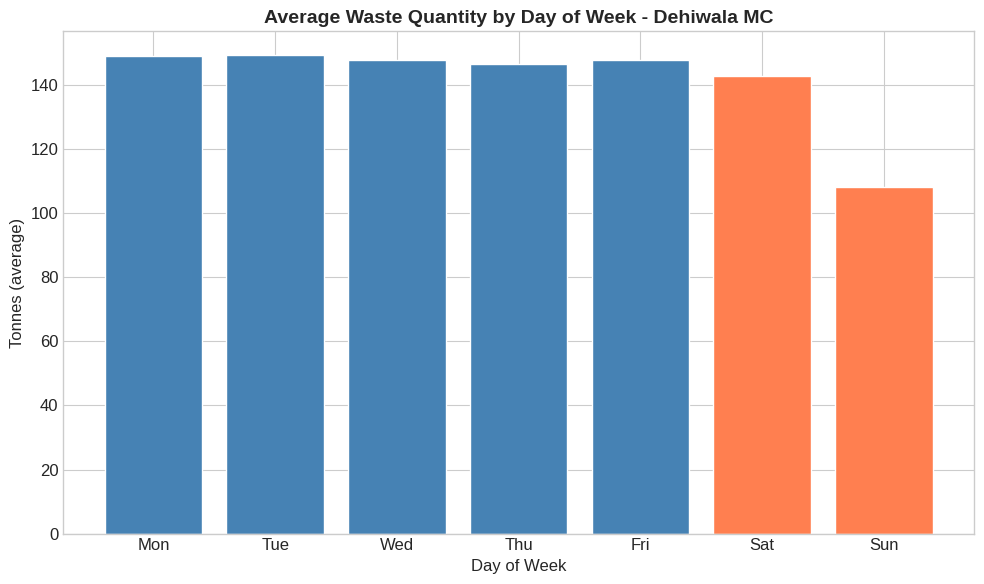

VISUALIZING MACRO SEASONALITY (Month)


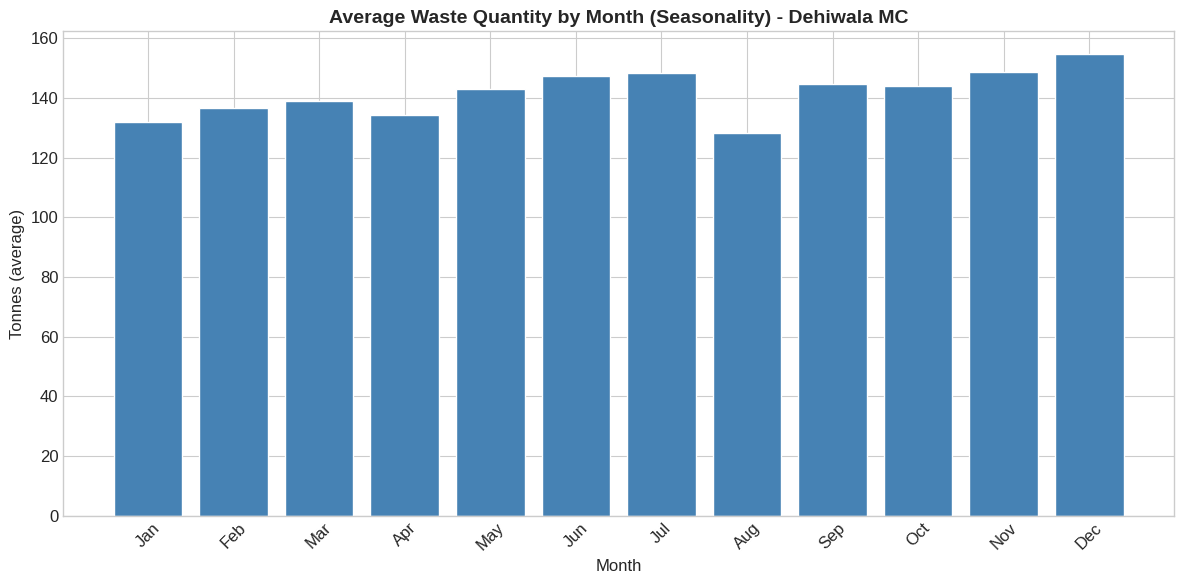

In [16]:
print("=" * 100)
print("VISUALIZING MACRO SEASONALITY (Day of Week)")
print("=" * 100)

# --- Plot 241: Average waste by day of week - Dehiwala MC ---
fig, ax = plt.subplots(figsize=(10, 6))

dow_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_data = daily.groupby('day_of_week')['total_tonnes'].mean()

ax.bar(range(7), dow_data.values, color=['steelblue']*5 + ['coral']*2, edgecolor='white')
ax.set_xticks(range(7))
ax.set_xticklabels(dow_names)
ax.set_title('Average Waste Quantity by Day of Week - Dehiwala MC', fontsize=14, fontweight='bold')
ax.set_ylabel('Tonnes (average)')
ax.set_xlabel('Day of Week')
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, '241_seasonality_dow_de.png'), dpi=150, bbox_inches='tight')
plt.show()


print("=" * 100)
print("VISUALIZING MACRO SEASONALITY (Month)")
print("=" * 100)

# --- Plot 242: Average waste month - Dehiwala MC ---
fig, ax = plt.subplots(figsize=(12, 6))

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_data = daily.groupby('month')['total_tonnes'].mean()

ax.bar(range(1, 13), month_data.values, color='steelblue', edgecolor='white')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names, rotation=45)
ax.set_title('Average Waste Quantity by Month (Seasonality) - Dehiwala MC', fontsize=14, fontweight='bold')
ax.set_ylabel('Tonnes (average)')
ax.set_xlabel('Month')
plt.tight_layout()

plt.savefig(os.path.join(VIS_DIR, '242_seasonality_month_de.png'), dpi=150, bbox_inches='tight')
plt.show()

VISUALIZING EFFECT OF WEEKENDS


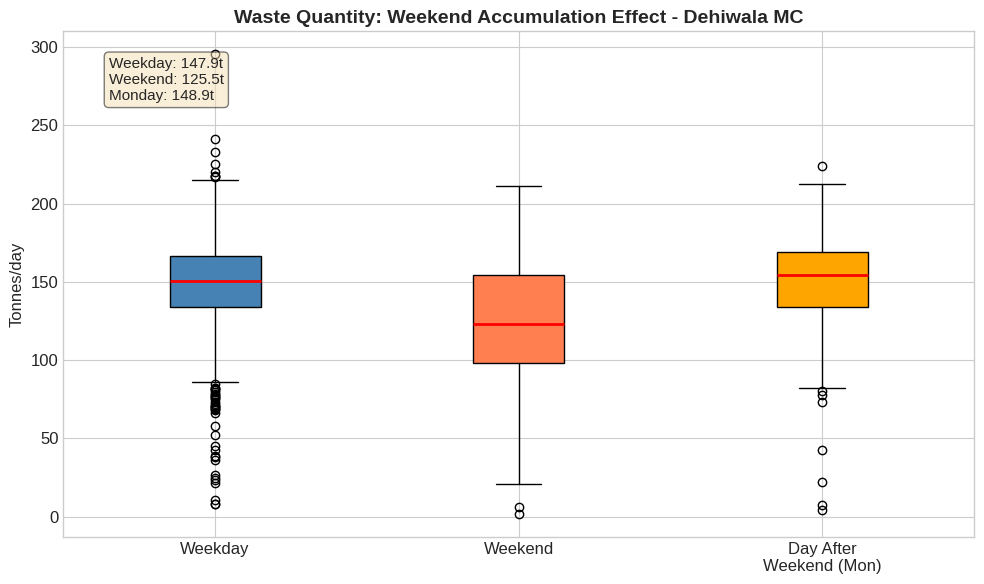

VISUALIZING EFFECT OF HOLIDAYS


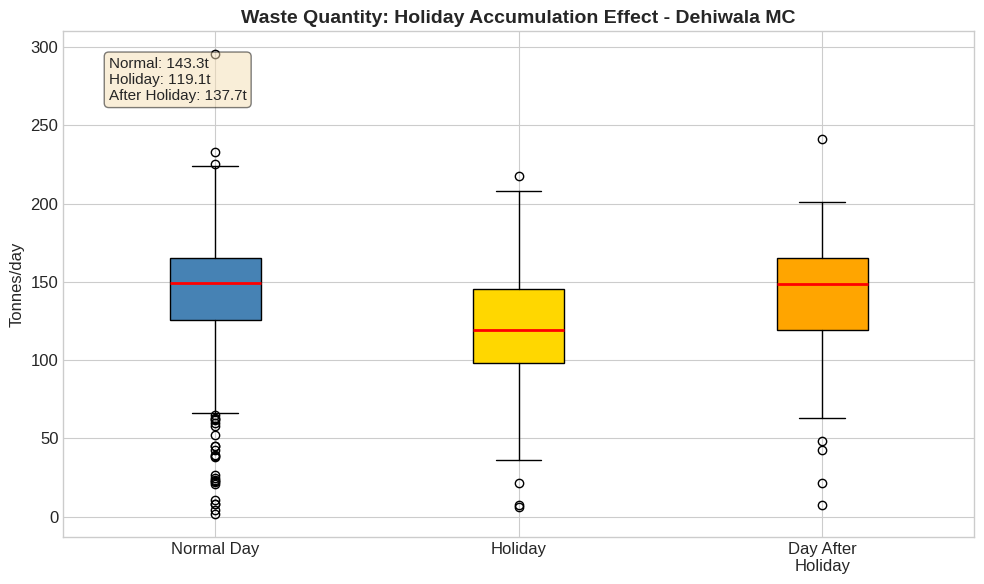

In [17]:
print("=" * 100)
print("VISUALIZING EFFECT OF WEEKENDS")
print("=" * 100)

# --- Plot 251: Weekend effect: Weekday vs Weekend boxplot - Dehiwala MC ---
fig, ax = plt.subplots(figsize=(10, 6))

weekend_data = [
    daily[(daily['is_weekend']==0) & (daily['is_after_weekend']==0)]['total_tonnes'].dropna(),
    daily[daily['is_weekend']==1]['total_tonnes'].dropna(),
    daily[daily['is_after_weekend']==1]['total_tonnes'].dropna()
]
bp = ax.boxplot(weekend_data, tick_labels=['Weekday', 'Weekend', 'Day After\nWeekend (Mon)'], patch_artist=True,
                medianprops=dict(color='red', linewidth=2))
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('coral')
bp['boxes'][2].set_facecolor('orange')

ax.set_title('Waste Quantity: Weekend Accumulation Effect - Dehiwala MC', fontsize=14, fontweight='bold')
ax.set_ylabel('Tonnes/day')

wd_mean = weekend_data[0].mean()
we_mean = weekend_data[1].mean()
after_mean = weekend_data[2].mean()

ax.text(0.05, 0.95,
        f'Weekday: {wd_mean:.1f}t\nWeekend: {we_mean:.1f}t\nMonday: {after_mean:.1f}t',
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()

plt.savefig(os.path.join(VIS_DIR, '251_weekend_accumulation_effect_de.png'), dpi=150, bbox_inches='tight')
plt.show()


print("=" * 100)
print("VISUALIZING EFFECT OF HOLIDAYS")
print("=" * 100)

# --- Plot 252: Holiday effect: Non-Holiday vs Holiday boxplot - Dehiwala MC ---
fig, ax = plt.subplots(figsize=(10, 6))

hol_data = [
    daily[(daily['is_holiday']==0) & (daily['is_after_holiday']==0)]['total_tonnes'].dropna(),
    daily[daily['is_holiday']==1]['total_tonnes'].dropna(),
    daily[daily['is_after_holiday']==1]['total_tonnes'].dropna()
]
bp = ax.boxplot(hol_data, tick_labels=['Normal Day', 'Holiday', 'Day After\nHoliday'], patch_artist=True,
                medianprops=dict(color='red', linewidth=2))
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('gold')
bp['boxes'][2].set_facecolor('orange')

ax.set_title('Waste Quantity: Holiday Accumulation Effect - Dehiwala MC', fontsize=14, fontweight='bold')
ax.set_ylabel('Tonnes/day')

norm_mean = hol_data[0].mean()
hol_mean = hol_data[1].mean()
after_hol_mean = hol_data[2].mean()

ax.text(0.05, 0.95,
        f'Normal: {norm_mean:.1f}t\nHoliday: {hol_mean:.1f}t\nAfter Holiday: {after_hol_mean:.1f}t',
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()

plt.savefig(os.path.join(VIS_DIR, '252_holiday_accumulation_effect_de.png'), dpi=150, bbox_inches='tight')
plt.show()

GAP ACCUMULATION ANALYSIS
Analyzing whether waste amount increases after gaps (accumulation effect)

Short gaps analyzed (<3 days): 5
Mean waste BEFORE gap: 129.5t
Mean waste AFTER gap:  146.7t
Change: +13.3%
Cases where after > before: 3/5 (60%)


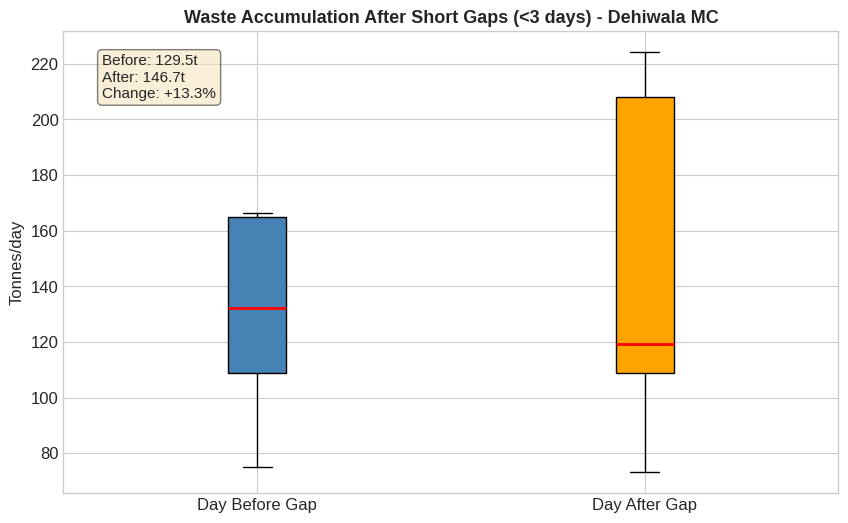

In [18]:
print("=" * 100)
print("GAP ACCUMULATION ANALYSIS")
print("=" * 100)
print("Analyzing whether waste amount increases after gaps (accumulation effect)\n")

# identify gaps shorter than 3 days (based on logic < 3)
daily['_is_missing'] = daily['was_gap'] if 'was_gap' in daily.columns else daily['total_kg'].isna()
daily['_gap_group'] = (daily['_is_missing'] != daily['_is_missing'].shift()).cumsum()

short_gaps = daily[daily['_is_missing']].groupby('_gap_group').agg(
    start=('date', 'first'),
    end=('date', 'last'),
    length=('date', 'count')
).reset_index(drop=True)
short_gaps = short_gaps[short_gaps['length'] < 3]

before_gap_values = []
after_gap_values = []
gap_lengths = []

for _, gap in short_gaps.iterrows():
    # day before gap
    day_before = gap['start'] - pd.Timedelta(days=1)
    before_row = daily[daily['date'] == day_before]

    if len(before_row) > 0 and pd.notna(before_row['total_tonnes'].values[0]):
        before_val = before_row['total_tonnes'].values[0]
    else:
        continue

    # day after gap
    day_after = gap['end'] + pd.Timedelta(days=1)
    after_row = daily[daily['date'] == day_after]
    if len(after_row) > 0 and pd.notna(after_row['total_tonnes'].values[0]):
        after_val = after_row['total_tonnes'].values[0]
    else:
        continue

    before_gap_values.append(before_val)
    after_gap_values.append(after_val)
    gap_lengths.append(gap['length'])

daily = daily.drop(columns=['_is_missing', '_gap_group'])

if len(before_gap_values) > 0:
    before_arr = np.array(before_gap_values)
    after_arr = np.array(after_gap_values)

    mean_before = before_arr.mean()
    mean_after = after_arr.mean()

    if mean_before != 0:
        pct_change = (mean_after - mean_before) / mean_before * 100
    else:
        pct_change = 0

    increased = (after_arr > before_arr).sum()

    print(f"Short gaps analyzed (<3 days): {len(before_gap_values)}")
    print(f"Mean waste BEFORE gap: {mean_before:.1f}t")
    print(f"Mean waste AFTER gap:  {mean_after:.1f}t")
    print(f"Change: {pct_change:+.1f}%")
    print(f"Cases where after > before: {increased}/{len(before_gap_values)} ({increased/len(before_gap_values)*100:.0f}%)")

    # --- Plot 253: Accumulation effect: Waste Amount after Gap - Dehiwala MC ---
    fig, ax = plt.subplots(figsize=(10, 6))

    bp = ax.boxplot([before_arr, after_arr], labels=['Day Before Gap', 'Day After Gap'],
                    patch_artist=True, medianprops=dict(color='red', linewidth=2))
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('orange')

    ax.set_title('Waste Accumulation After Short Gaps (<3 days) - Dehiwala MC', fontsize=13, fontweight='bold')
    ax.set_ylabel('Tonnes/day')

    text_str = f'Before: {mean_before:.1f}t\nAfter: {mean_after:.1f}t\nChange: {pct_change:+.1f}%'
    ax.text(0.05, 0.95, text_str,
            transform=ax.transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.savefig(os.path.join(VIS_DIR, '253_gap_accumulation_effect_de.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No valid short gaps found for analysis.")

VISUALIZING OVERALL WEATHER EFFECTS (Bottom 25% vs Top 25%)


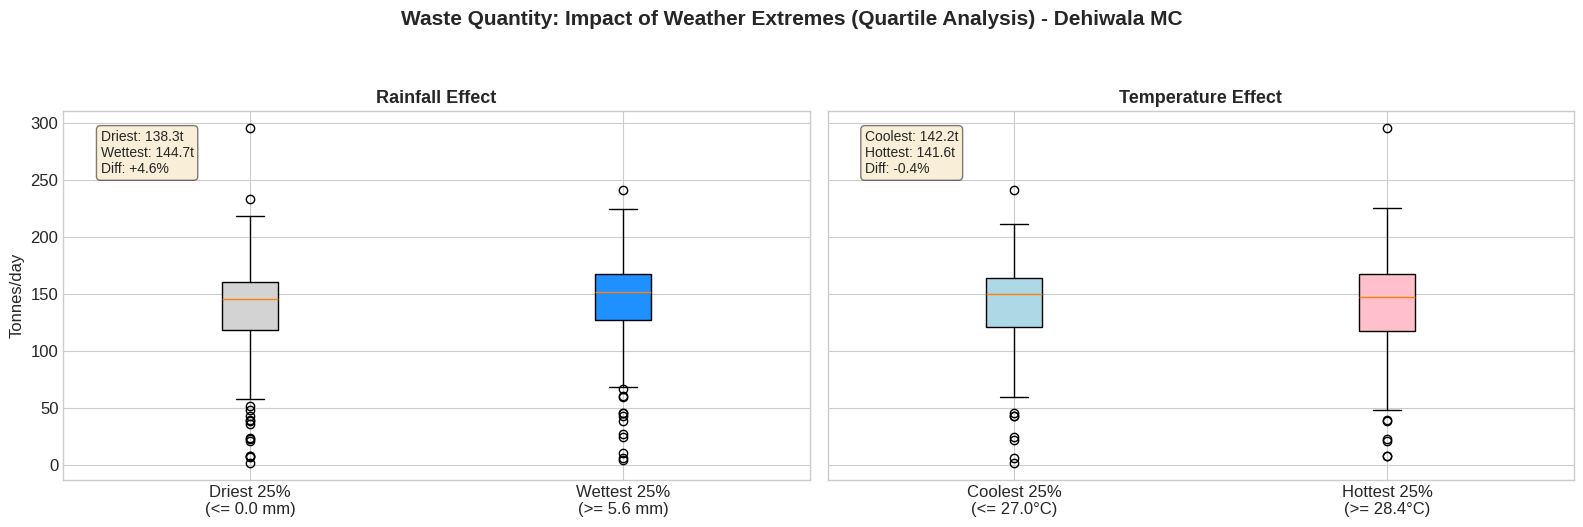

In [19]:
print("=" * 100)
print("VISUALIZING OVERALL WEATHER EFFECTS (Bottom 25% vs Top 25%)")
print("=" * 100)

# --- Plot 261: Weather impact: Quartile comparison for rain, temperature, wind - Dehiwala MC ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# rainfall effect
ax = axes[0]
prcp_q1, prcp_q3 = daily['prcp'].quantile(0.25), daily['prcp'].quantile(0.75)
driest = daily[daily['prcp'] <= prcp_q1]['total_tonnes'].dropna()
wettest = daily[daily['prcp'] >= prcp_q3]['total_tonnes'].dropna()

bp1 = ax.boxplot([driest, wettest],
                 tick_labels=[f'Driest 25%\n(<= {prcp_q1:.1f} mm)', f'Wettest 25%\n(>= {prcp_q3:.1f} mm)'],
                 patch_artist=True)
bp1['boxes'][0].set_facecolor('lightgray')
bp1['boxes'][1].set_facecolor('dodgerblue')
ax.set_title('Rainfall Effect', fontsize=13, fontweight='bold')
ax.set_ylabel('Tonnes/day')

prcp_diff = (wettest.mean() - driest.mean()) / driest.mean() * 100
ax.text(0.05, 0.95, f'Driest: {driest.mean():.1f}t\nWettest: {wettest.mean():.1f}t\nDiff: {"+" if prcp_diff>0 else ""}{prcp_diff:.1f}%',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))


# temperature effect
ax = axes[1]
temp_q1, temp_q3 = daily['tavg'].quantile(0.25), daily['tavg'].quantile(0.75)
coldest = daily[daily['tavg'] <= temp_q1]['total_tonnes'].dropna()
hottest = daily[daily['tavg'] >= temp_q3]['total_tonnes'].dropna()

bp2 = ax.boxplot([coldest, hottest],
                 tick_labels=[f'Coolest 25%\n(<= {temp_q1:.1f}°C)', f'Hottest 25%\n(>= {temp_q3:.1f}°C)'],
                 patch_artist=True)
bp2['boxes'][0].set_facecolor('lightblue')
bp2['boxes'][1].set_facecolor('pink')
ax.set_title('Temperature Effect', fontsize=13, fontweight='bold')

temp_diff = (hottest.mean() - coldest.mean()) / coldest.mean() * 100
ax.text(0.05, 0.95, f'Coolest: {coldest.mean():.1f}t\nHottest: {hottest.mean():.1f}t\nDiff: {"+" if temp_diff>0 else ""}{temp_diff:.1f}%',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))


plt.suptitle('Waste Quantity: Impact of Weather Extremes (Quartile Analysis) - Dehiwala MC',
             fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()

plt.savefig(os.path.join(VIS_DIR, '261_weather_effect_de.png'), dpi=150, bbox_inches='tight')
plt.show()

VISUALIZING CORRELATION HEATMAP


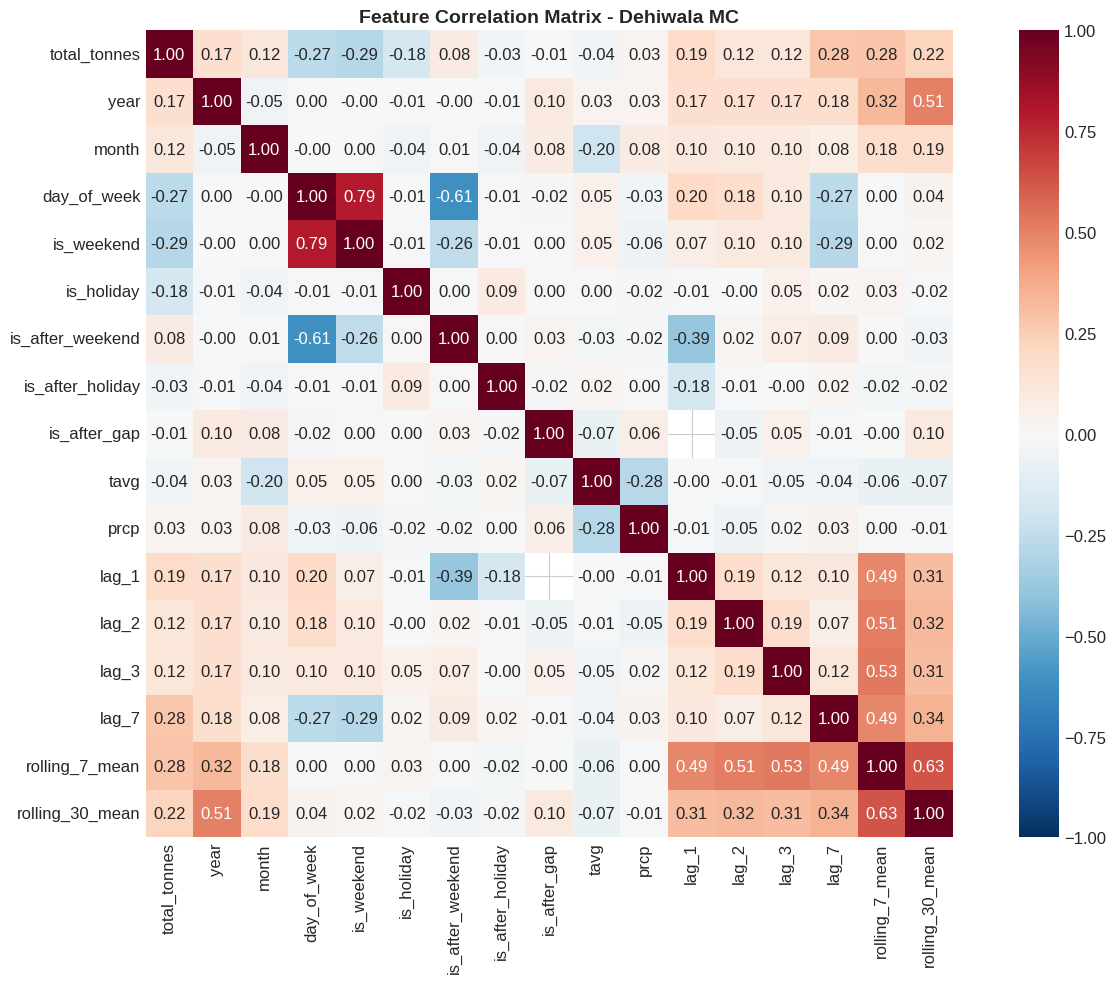

Strongest correlations with daily waste amount:
  is_weekend           -0.288
  rolling_7_mean       +0.283
  lag_7                +0.276
  day_of_week          -0.272
  rolling_30_mean      +0.222
  lag_1                +0.190
  is_holiday           -0.176
  year                 +0.167
  lag_3                +0.125
  lag_2                +0.123
  month                +0.116
  is_after_weekend     +0.083
  tavg                 -0.038
  is_after_holiday     -0.034
  prcp                 +0.026
  is_after_gap         -0.007


In [20]:
print("=" * 100)
print("VISUALIZING CORRELATION HEATMAP")
print("=" * 100)

# dropping first 30 rows where lag/rolling features are incomplete
daily_clean = daily.iloc[30:].reset_index(drop=True)

# --- Plot 271: Correlation heatmap: feature vs target relationship - Dehiwala MC ---

corr_features = ['total_tonnes', 'year', 'month', 'day_of_week', 'is_weekend', 'is_holiday',
                 'is_after_weekend', 'is_after_holiday', 'is_after_gap', 'tavg', 'prcp',
                 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'rolling_7_mean', 'rolling_30_mean']

corr_matrix = daily_clean[corr_features].corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Feature Correlation Matrix - Dehiwala MC', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig(os.path.join(VIS_DIR, '271_correlation_heatmap_de.png'), dpi=150, bbox_inches='tight')
plt.show()


# ranking
target_corr = corr_matrix['total_tonnes'].drop('total_tonnes').sort_values(key=abs, ascending=False)
print("Strongest correlations with daily waste amount:")
for feat, val in target_corr.items():
    print(f"  {feat:<20s} {val:+.3f}")

VISUALIZING AUTOCORRELATION ACF/PACF


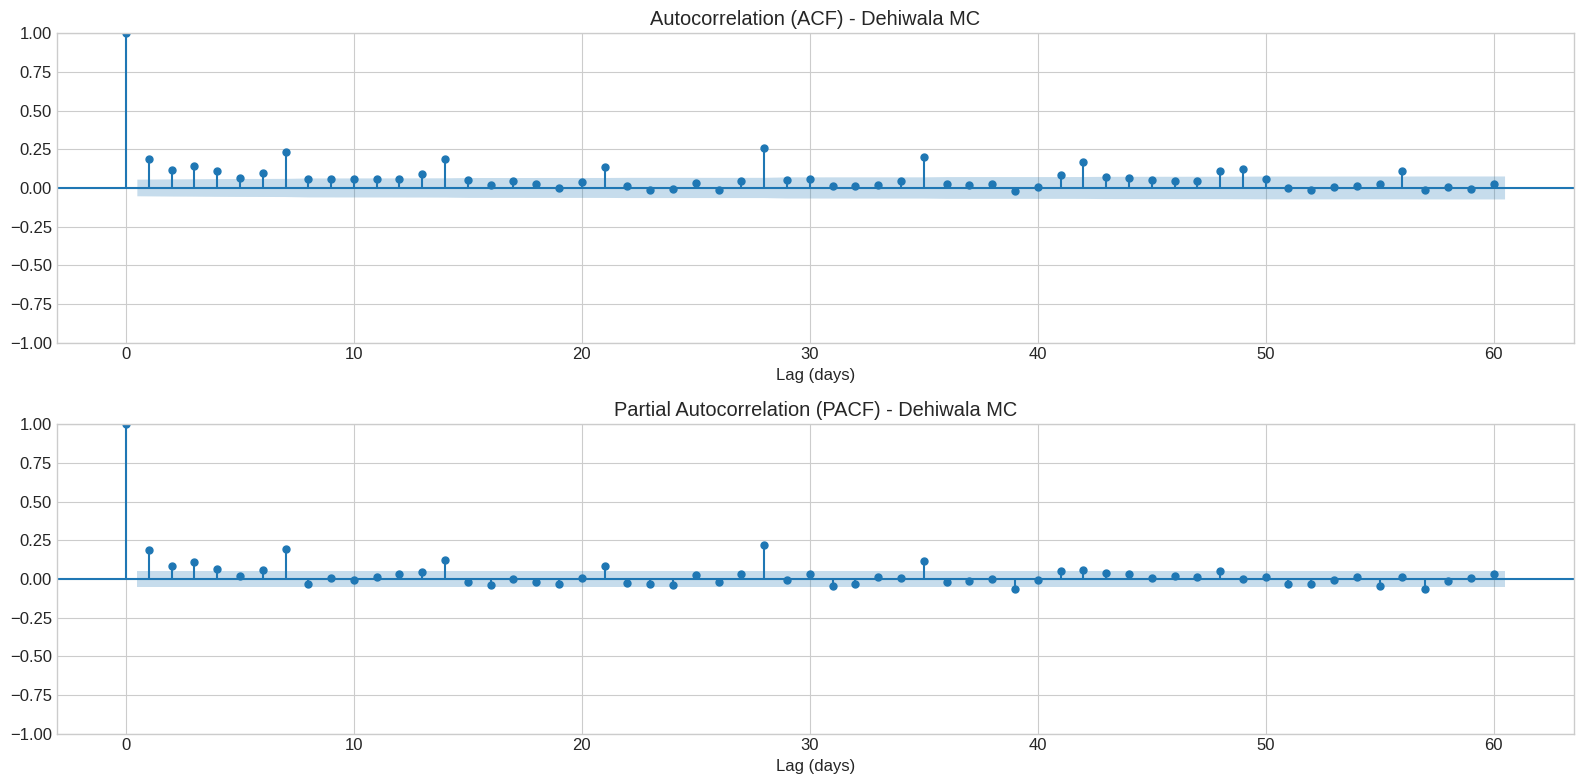

In [21]:
print("=" * 100)
print("VISUALIZING AUTOCORRELATION ACF/PACF")
print("=" * 100)

# --- Plot 272: Autocorrelation analysis (ACF/PACF) for SARIMA parameter selection - Dehiwala MC ---
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

daily_clean = daily.dropna().reset_index(drop=True)

plot_acf(daily_clean['total_tonnes'], lags=60, ax=axes[0], title='Autocorrelation (ACF) - Dehiwala MC')
plot_pacf(daily_clean['total_tonnes'], lags=60, ax=axes[1], title='Partial Autocorrelation (PACF) - Dehiwala MC')

axes[0].set_xlabel('Lag (days)')
axes[1].set_xlabel('Lag (days)')
plt.tight_layout()

plt.savefig(os.path.join(VIS_DIR, '272_acf_pacf_de.png'), dpi=150, bbox_inches='tight')
plt.show()

In [22]:
print("=" * 100)
print("STATIONARITY TEST (Augmented Dickey-Fuller)")
print("=" * 100)

from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(daily_clean['total_tonnes'])

print("Augmented Dickey-Fuller Test:")
print(f"  Test Statistic:  {adf_result[0]:.4f}")
print(f"  P-Value:         {adf_result[1]:.6f}")
print(f"  Lags Used:       {adf_result[2]}")
print(f"  Observations:    {adf_result[3]}")
print(f"  Critical Values:")
for key, val in adf_result[4].items():
    print(f"    {key}: {val:.4f}")

if adf_result[1] < 0.05:
    print("\n  → Result: Series is STATIONARY (p < 0.05). No differencing needed.")
else:
    print("\n  → Result: Series is NON-STATIONARY (p >= 0.05). Differencing recommended for SARIMA.")

STATIONARITY TEST (Augmented Dickey-Fuller)
Augmented Dickey-Fuller Test:
  Test Statistic:  -5.9482
  P-Value:         0.000000
  Lags Used:       13
  Observations:    1309
  Critical Values:
    1%: -3.4354
    5%: -2.8638
    10%: -2.5679

  → Result: Series is STATIONARY (p < 0.05). No differencing needed.


# Processed Data saving

In [23]:
print("=" * 100)
print("FINAL DATASET CLEANUP & EXPORT")
print("=" * 100)

# dropping first 30 rows (lag/rolling features not yet computable)
daily_export = daily.iloc[30:].reset_index(drop=True)

print(f"Total Rows:          {daily.shape[0]}")
print(f"First 30 dropped:    30 (incomplete lag/rolling features)")
print(f"Exported Rows:       {daily_export.shape[0]}")
print(f"  - with target:     {daily_export['total_tonnes'].notna().sum()}")
print(f"  - target NaN:      {daily_export['total_tonnes'].isna().sum()}")
print(f"  - any feature NaN: {daily_export.isna().any(axis=1).sum()}")
print(f"Features:            {daily_export.shape[1]}")

# export processed dataset
output_path = os.path.join(RES_DIR, 'dehiwala_processed.csv')
daily_export.to_csv(output_path, index=False)

print("-" * 100)
print(f"SUCCESS: Processed dataset saved to:\n{output_path}")
print("-" * 100)

FINAL DATASET CLEANUP & EXPORT
Total Rows:          1461
First 30 dropped:    30 (incomplete lag/rolling features)
Exported Rows:       1431
  - with target:     1403
  - target NaN:      28
  - any feature NaN: 108
Features:            30
----------------------------------------------------------------------------------------------------
SUCCESS: Processed dataset saved to:
/content/drive/MyDrive/DP/02_processed_data/dehiwala_processed.csv
----------------------------------------------------------------------------------------------------


# EDA Summary

In [24]:
print("\n" + "=" * 100)
print("FINAL DATA PIPELINE & EDA SUMMARY - Dehiwala MC")
print("=" * 100)

total_days = len(daily)
missing = daily['was_gap'].sum()
valid = total_days - missing

avg_temp = daily['tavg'].mean()
total_rainy = (daily['prcp'] > 0).sum()

valid_daily = daily[~daily['was_gap']]

# weekend stats
wd_mean = valid_daily[(valid_daily['is_weekend']==0) & (valid_daily['is_after_weekend']==0)]['total_tonnes'].mean()
we_mean = valid_daily[valid_daily['is_weekend']==1]['total_tonnes'].mean()
mon_mean = valid_daily[valid_daily['is_after_weekend']==1]['total_tonnes'].mean()

# holiday stats
norm_mean = valid_daily[(valid_daily['is_holiday']==0) & (valid_daily['is_after_holiday']==0)]['total_tonnes'].mean()
hol_mean = valid_daily[valid_daily['is_holiday']==1]['total_tonnes'].mean()
after_hol = valid_daily[valid_daily['is_after_holiday']==1]['total_tonnes'].mean()

# gap accumulation stats
after_gap_days = valid_daily[valid_daily['is_after_gap']==1]['total_tonnes']
non_gap_days = valid_daily[valid_daily['is_after_gap']==0]['total_tonnes']
after_gap_mean = after_gap_days.mean() if len(after_gap_days) > 0 else 0
non_gap_mean = non_gap_days.mean() if len(non_gap_days) > 0 else 0
gap_acc_pct = (after_gap_mean - non_gap_mean) / non_gap_mean * 100 if non_gap_mean != 0 else 0

# correlations
corr_features = ['total_tonnes', 'year', 'month', 'day_of_week', 'is_weekend', 'is_holiday',
                 'is_after_weekend', 'is_after_holiday', 'tavg', 'prcp',
                 'lag_1', 'lag_7', 'rolling_7_mean', 'rolling_30_mean', 'is_after_gap']
daily_corr = daily.dropna(subset=corr_features)
tc = daily_corr[corr_features].corr()['total_tonnes'].drop('total_tonnes').sort_values(key=abs, ascending=False)
top5 = '\n'.join([f'    {f:<20s} {v:+.3f}' for f, v in tc.head(5).items()])

# conditional zero-fill stats
zero_filled = ((daily['was_gap']) & (daily['total_kg'] == 0)).sum()
still_nan = daily['total_kg'].isna().sum()

print(f'''
DATASET:
  Waste types:     MSW + Sorted Organic Waste + Polythyne & Regiform + Non Biodegradable + Biodegradable
  Time range:      {daily['date'].min().date()} → {daily['date'].max().date()} ({total_days} days)
  Valid days:      {valid} ({valid/total_days*100:.1f}%)
  Original gaps:   {missing} days ({missing/total_days*100:.1f}%)
    → Zero-filled: {zero_filled} days (short gaps with accumulation effect)
    → Still NaN:   {still_nan} days (remaining gaps, no imputation)

APPROACH:
  - No outlier removal (legitimate after waste type filter)
  - Short gaps (1-3d) filled with 0 IF day after > 1.15x 30d avg (accumulation confirmed)
  - Remaining gaps left as NaN (no imputation)
  - Lag/rolling features: NaN propagates naturally
  - Rolling features shifted by 1 day (no data leakage)

KEY FINDINGS:
  Weekend:       {wd_mean:.1f}t (weekday) vs {we_mean:.1f}t (weekend) vs {mon_mean:.1f}t (Monday)
  Holiday:       {norm_mean:.1f}t (normal) vs {hol_mean:.1f}t (holiday) vs {after_hol:.1f}t (after)
  Gap accum.:    {non_gap_mean:.1f}t (normal) vs {after_gap_mean:.1f}t (after gap) → {gap_acc_pct:+.1f}%
  After-gap days: {len(after_gap_days)} flagged as is_after_gap
  Weather:       <5% variance across quartiles
  Avg temp:      {avg_temp:.1f}°C, Rainy days: {total_rainy}

TOP CORRELATIONS:
{top5}

FEATURES ({daily.shape[1]} total):
  Calendar, binary (weekend/holiday/after_gap), weather, lag, rolling, cyclical
''')
print("=" * 100)


FINAL DATA PIPELINE & EDA SUMMARY - Dehiwala MC

DATASET:
  Waste types:     MSW + Sorted Organic Waste + Polythyne & Regiform + Non Biodegradable + Biodegradable
  Time range:      2012-01-01 → 2015-12-31 (1461 days)
  Valid days:      1433 (98.1%)
  Original gaps:   28 days (1.9%)
    → Zero-filled: 5 days (short gaps with accumulation effect)
    → Still NaN:   23 days (remaining gaps, no imputation)

APPROACH:
  - No outlier removal (legitimate after waste type filter)
  - Short gaps (1-3d) filled with 0 IF day after > 1.15x 30d avg (accumulation confirmed)
  - Remaining gaps left as NaN (no imputation)
  - Lag/rolling features: NaN propagates naturally
  - Rolling features shifted by 1 day (no data leakage)

KEY FINDINGS:
  Weekend:       147.9t (weekday) vs 125.5t (weekend) vs 148.9t (Monday)
  Holiday:       143.3t (normal) vs 119.1t (holiday) vs 137.7t (after)
  Gap accum.:    141.7t (normal) vs 139.2t (after gap) → -1.8%
  After-gap days: 8 flagged as is_after_gap
  Weather: 